In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [21]:
df1=pd.read_csv("gurgaon_properties_missing_value_imputation.csv")

In [22]:
df1.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss the leaf,sector 85,1.07,6524.0,2,2,3,21.0,Relatively New,1439.0,0,0,0,1,0,0,67
1,flat,la vida by tata housing,sector 113,2.78,11346.0,3,3,3,3.0,New Property,2599.0,1,1,0,0,0,0,174
2,flat,whiteland the aspen,sector 76,3.50,11917.0,3,4,3,8.0,Under Construction,2937.0,0,0,0,0,0,0,0
3,flat,sanskriti apartments,sector 43,2.50,13513.0,3,2,3,5.0,Old Property,1623.0,1,0,0,0,0,0,0
4,flat,tulip violet,sector 69,1.42,8998.0,3,3,2,8.0,Relatively New,1384.0,0,0,0,1,0,2,94


In [17]:
df=pd.read_csv("latlong.csv")

In [18]:
df.head()

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [19]:
# Extract latitude and longitude
df[['lat', 'lat_dir', 'lon', 'lon_dir']] = df['coordinates'].str.extract(
    r'([\d.]+)°\s*([NS]),\s*([\d.]+)°\s*([EW])'
)

# Convert to proper numeric values
df['latitude'] = df['lat'].astype(float)
df['longitude'] = df['lon'].astype(float)

# Handle South & West (if present)
df.loc[df['lat_dir'] == 'S', 'latitude'] *= -1
df.loc[df['lon_dir'] == 'W', 'longitude'] *= -1

# Drop extra columns
df.drop(columns=['lat', 'lat_dir', 'lon', 'lon_dir'], inplace=True)


In [20]:
df.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [23]:
df=df.merge(df1)

In [24]:
df.head()

,sector,coordinates,latitude,longitude,property_type,society,price,price_per_sqft,bedRoom,bathroom,...,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456,flat,the nav manesar apartment,0.85,3953.0,3,3,...,5.0,Moderately Old,1886.0,0,1,0,0,0,0,5
1,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456,flat,samadhan shri kamal cghs,2.01,11426.0,4,4,...,10.0,Moderately Old,2000.0,0,0,0,0,0,1,0
2,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456,house,independent,4.75,10556.0,6,7,...,4.0,Moderately Old,4500.0,0,0,0,0,0,0,0
3,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456,house,independent,1.85,16003.0,4,3,...,3.0,Moderately Old,1314.0,0,0,0,0,0,0,0
4,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456,flat,dnha cghs,0.85,3864.0,3,3,...,5.0,Moderately Old,2200.0,0,0,0,0,0,0,0


In [44]:
new_df=df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()

In [45]:
new_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.888889,3004.777778,28.4484,77.0210
manesar,0.961515,4717.606061,1998.709091,28.3515,76.9428
sector 1,1.860000,8249.500000,2319.666667,28.3663,76.9456
sector 102,1.681327,10640.946903,1528.141593,28.4750,76.9715
sector 103,1.524762,7404.476190,1892.023810,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.937500,5885.211538,1581.126731,28.4079,76.9153
sector 93,0.808182,8517.363636,946.454545,28.4153,76.9326
sector 95,0.521538,5531.692308,1103.211538,28.4172,76.9081


In [46]:
import plotly.express as px

C:\Users\hp\AppData\Local\Temp\ipykernel_3252\2021474615.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



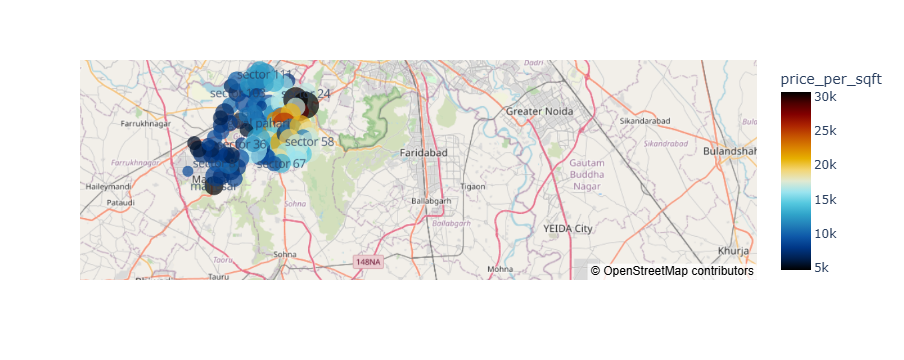

In [47]:
fig=px.scatter_mapbox(new_df,lat='latitude',lon='longitude',color='price_per_sqft',size='built_up_area',
                     color_continuous_scale=px.colors.cyclical.IceFire,zoom=10,
                     mapbox_style='open-street-map',text=new_df.index)
fig.show()

In [57]:
new_df.to_csv('new_df2.csv',index=False)

In [55]:
new_df.reset_index(inplace=True)

In [56]:
new_df

,sector,price,price_per_sqft,built_up_area,latitude,longitude
0,gwal pahari,3.192222,9585.888889,3004.777778,28.4484,77.0210
1,manesar,0.961515,4717.606061,1998.709091,28.3515,76.9428
2,sector 1,1.860000,8249.500000,2319.666667,28.3663,76.9456
3,sector 102,1.681327,10640.946903,1528.141593,28.4750,76.9715
4,sector 103,1.524762,7404.476190,1892.023810,28.4949,76.9845
...,...,...,...,...,...,...
100,sector 92,0.937500,5885.211538,1581.126731,28.4079,76.9153
101,sector 93,0.808182,8517.363636,946.454545,28.4153,76.9326
102,sector 95,0.521538,5531.692308,1103.211538,28.4172,76.9081
103,sector 99,1.695625,7163.000000,1978.375000,28.4640,76.9614


In [58]:
df=pd.read_csv("gurgaon_properties.csv")

In [59]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,3,pooja room,"245, Sector 85 Gurgaon, Gurgaon, Haryana",21.0,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",This lovely 2 bhk apartment/flat in sector 85 ...,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4.5 out of 5', 'Construction4.5 ou..."
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,3,"study room,servant room","Sector 113 Gurgaon , Gurgaon, Haryana",3.0,North,0 to 1 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...",La vida by tata housing is one of the most pop...,"['2 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",NaN
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,3,not available,"Sector 76, Delhi Gurgaon Expressway, Sector 76...",8.0,NaN,undefined,"['S.R.S. Hospital and Critical Care Unit', 'Pe...",Multistorey apartment is available for sale. I...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,3,study room,"B-505, Sector 43 Gurgaon, Gurgaon, Haryana",5.0,East,10+ Year Old,"['Huda city centre metro station', 'Hanuman Ma...",Residential apartment for sell.Located in sect...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E..."
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,2,pooja room,"Sector 69 Gurgaon, Gurgaon, Haryana",8.0,East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",A well maintained 3 bhk flat available on sale...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Intercom Facility',...","['Green Area5 out of 5', 'Construction4 out of..."


In [64]:
wordcloud_df=df.merge(df1,left_index=True,right_index=True)[['features','sector']]

In [65]:
wordcloud_df.head()

,features,sector
0,"['Power Back-up', 'Intercom Facility', 'Lift(s...",sector 85
1,"['Centrally Air Conditioned', 'Water purifier'...",sector 113
2,NaN,sector 76
3,NaN,sector 43
4,"['Security / Fire Alarm', 'Intercom Facility',...",sector 69


In [68]:
import ast
main=[]
for i in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(i)

In [69]:
main

['Power Back-up',
 'Intercom Facility',
 'Lift(s)',
 'Swimming Pool',
 'Maintenance Staff',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Rain Water Harvesting',
 'Centrally Air Conditioned',
 'Water purifier',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Security / Fire

In [72]:
from wordcloud import WordCloud

In [75]:
feature_text=' '.join(main)

In [76]:
feature_text

'Power Back-up Intercom Facility Lift(s) Swimming Pool Maintenance Staff Park Security Personnel Internet/wi-fi connectivity Shopping Centre Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage No open drainage around Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spaci

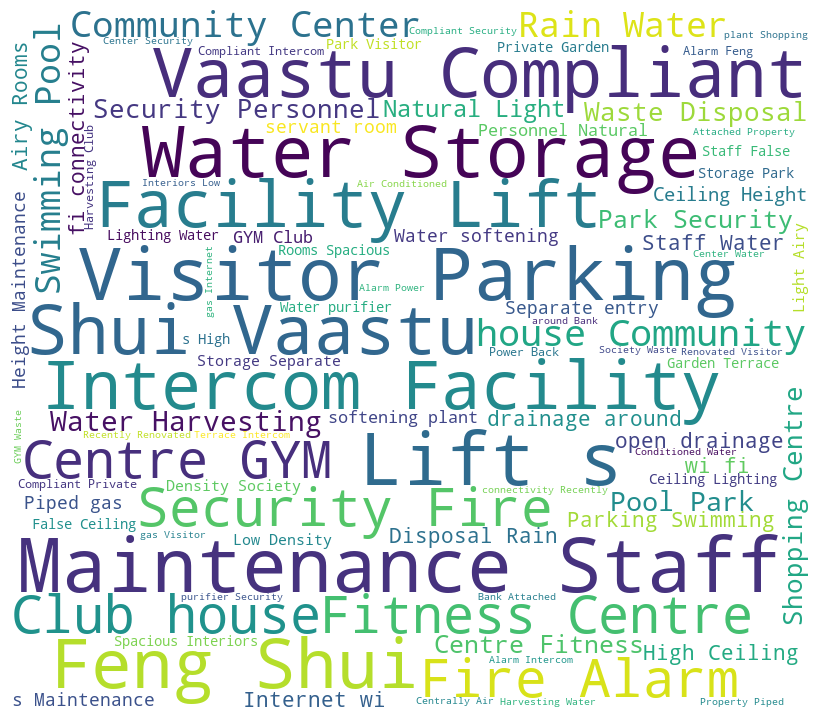

In [83]:
plt.rcParams['font.family']='Arial'
wordcloud=WordCloud(width=800,height=700,
                    background_color='white',
                   min_font_size=10).generate(feature_text)

plt.figure(figsize=(8,8),facecolor=None)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [80]:
import pickle 


In [82]:
with open('feature_text.pkl','wb') as f:
    pickle.dump(feature_text,f)

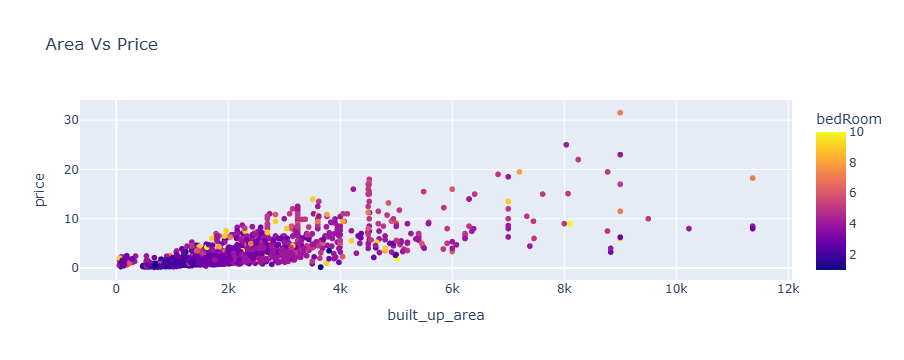

In [86]:
fig=px.scatter(df1,x='built_up_area',y='price',color='bedRoom',title='Area Vs Price')
fig.show()